
   ÉTAPE 1 — CHARGEMENT DES 9 TABLES BRUTES
   Source : data/raw/ — lecture seule

Table        |   Lignes | Colonnes
--------------------------------------
  orders       |    99441 |        8
  items        |   112650 |        7
  payments     |   103886 |        5
  reviews      |    99224 |        7
  products     |    32951 |        9
  customers    |    99441 |        5
  sellers      |     3095 |        4
  geo          |  1000163 |        5
  transl       |       71 |        2

   ÉTAPE 2 — AUDIT STRUCTURE : TOUTES LES TABLES


  TABLE : ORDERS  — 99441 lignes × 8 colonnes
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Aperçu :
                           order_id                       customer_

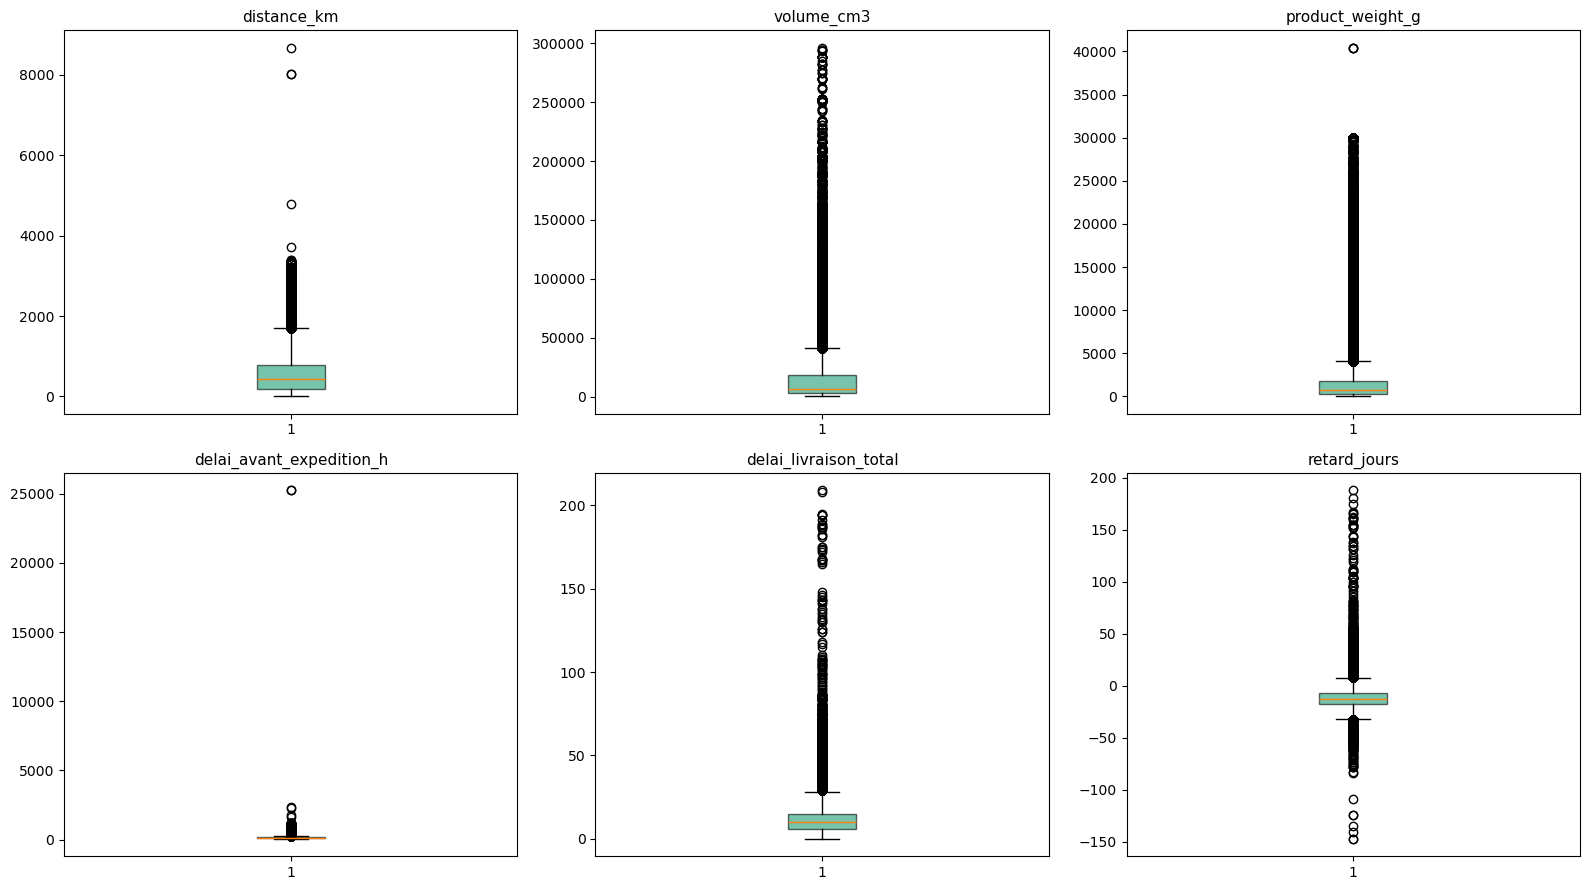

✓ Figure sauvegardée : audit_boxplots_logistique.png

   ÉTAPE 13 — ISOLATION FOREST (détection multivariée)
   Détecte des combinaisons anormales invisibles en IQR seul

✓ Anomalies multivariées détectées : 2194 (2.00%)

--- Comparaison : moyenne sur anomalies vs normal ---
                      distance_km  volume_cm3  product_weight_g  \
anomalie_multivariee                                              
0                           589.2     13770.1            1858.4   
1                           937.1     85109.7           13328.2   

                      delai_avant_expedition_h  delai_livraison_total  \
anomalie_multivariee                                                    
0                                        155.1                   11.5   
1                                        327.2                   36.3   

                      retard_jours  
anomalie_multivariee                
0                            -12.3  
1                              2.3  

   RAPPORT DE

In [1]:
# ============================================================
# 01_data_audit.ipynb — AUDIT COMPLET DES DONNÉES
# Nouvelle problématique : prédiction du risque de retard
# Objectif : observer, documenter, ne rien modifier
# ============================================================

import sys
sys.path.append('..')
from src.utils import *

from sklearn.ensemble import IsolationForest


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 1 — CHARGEMENT DES 9 TABLES BRUTES")
print("   Source : data/raw/ — lecture seule")
print("="*60 + "\n")
# -------------------------------------------------------

orders    = pd.read_csv('../data/raw/olist_orders_dataset.csv')
items     = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
payments  = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
reviews   = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
products  = pd.read_csv('../data/raw/olist_products_dataset.csv')
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')
sellers   = pd.read_csv('../data/raw/olist_sellers_dataset.csv')
geo       = pd.read_csv('../data/raw/olist_geolocation_dataset.csv')
transl    = pd.read_csv('../data/raw/product_category_name_translation.csv')

tables = {
    'orders': orders, 'items': items, 'payments': payments,
    'reviews': reviews, 'products': products, 'customers': customers,
    'sellers': sellers, 'geo': geo, 'transl': transl
}

print(f"{'Table':<12} | {'Lignes':>8} | {'Colonnes':>8}")
print("-" * 38)
for name, df in tables.items():
    print(f"  {name:<12} | {len(df):>8} | {df.shape[1]:>8}")


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 2 — AUDIT STRUCTURE : TOUTES LES TABLES")
print("="*60 + "\n")
# -------------------------------------------------------

for name, df in tables.items():
    audit_table(name, df)


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 3 — RAPPORT DES VALEURS MANQUANTES")
print("="*60 + "\n")
# -------------------------------------------------------

rapport_nulls(tables)


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 4 — AUDIT DOUBLONS : TOUTES LES TABLES")
print("="*60 + "\n")
# -------------------------------------------------------

print(f"{'Table':<12} | {'Doublons':>10} | {'% total':>8}")
print("-" * 40)
for name, df in tables.items():
    n_dup = df.duplicated().sum()
    pct = n_dup / len(df) * 100
    print(f"  {name:<12} | {n_dup:>10} | {pct:>7.2f}%")


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 5 — AUDIT SPÉCIFIQUE LOGISTIQUE : orders")
print("   Focus : cohérence des 4 dates du cycle de vie")
print("="*60 + "\n")
# -------------------------------------------------------

print("--- Nulls par colonne date ---")
date_cols = ['order_approved_at', 'order_delivered_carrier_date',
             'order_delivered_customer_date']
for col in date_cols:
    print(f"  {col:<35} {orders[col].isnull().sum()} nulls")

print("\n--- Statut des commandes sans date de livraison ---")
mask = orders['order_delivered_customer_date'].isnull()
print(orders[mask]['order_status'].value_counts())

# Vérifier la cohérence chronologique : approved < carrier < delivered
orders_dt = orders.copy()
for c in ['order_purchase_timestamp'] + date_cols + ['order_estimated_delivery_date']:
    orders_dt[c] = pd.to_datetime(orders_dt[c], errors='coerce')

incoherent = orders_dt[
    (orders_dt['order_delivered_customer_date'] < orders_dt['order_purchase_timestamp'])
]
print(f"\n⚠️  Commandes avec livraison AVANT achat (incohérence) : {len(incoherent)}")


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 6 — AUDIT SPÉCIFIQUE LOGISTIQUE : items")
print("   Focus : seller_id, shipping_limit_date, poids indirect")
print("="*60 + "\n")
# -------------------------------------------------------

print("--- Nulls par colonne ---")
print(items.isnull().sum())

print(f"\n--- Nombre de vendeurs uniques ---")
print(f"  seller_id uniques : {items['seller_id'].nunique()}")

print(f"\n--- Cohérence shipping_limit_date vs order_purchase_timestamp ---")
items_check = items.merge(orders[['order_id','order_purchase_timestamp']], on='order_id', how='left')
items_check['shipping_limit_date'] = pd.to_datetime(items_check['shipping_limit_date'], errors='coerce')
items_check['order_purchase_timestamp'] = pd.to_datetime(items_check['order_purchase_timestamp'], errors='coerce')
avant_achat = (items_check['shipping_limit_date'] < items_check['order_purchase_timestamp']).sum()
print(f"  Limite d'expédition avant l'achat (incohérent) : {avant_achat}")


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 7 — AUDIT SPÉCIFIQUE LOGISTIQUE : products")
print("   Focus : poids et dimensions → volume du colis")
print("="*60 + "\n")
# -------------------------------------------------------

print("--- Nulls par colonne ---")
print(products.isnull().sum())

dims = ['product_weight_g','product_length_cm','product_height_cm','product_width_cm']
print(f"\n--- Statistiques dimensions (utiles pour le volume) ---")
print(products[dims].describe())

# Produits avec poids ou dimensions à 0 (anomalie)
zero_weight = (products['product_weight_g'] == 0).sum()
print(f"\n⚠️  Produits avec poids = 0 : {zero_weight}")


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 8 — AUDIT SPÉCIFIQUE LOGISTIQUE : customers & sellers")
print("   Focus : couverture géographique pour calcul de distance")
print("="*60 + "\n")
# -------------------------------------------------------

print("--- customers : états représentés ---")
print(f"  {customers['customer_state'].nunique()} états")
print(customers['customer_state'].value_counts().head(10))

print(f"\n--- sellers : états représentés ---")
print(f"  {sellers['seller_state'].nunique()} états")
print(sellers['seller_state'].value_counts().head(10))

# Zip codes présents dans customers/sellers mais absents de geo ?
zips_geo = set(geo['geolocation_zip_code_prefix'].unique())
zips_cust = set(customers['customer_zip_code_prefix'].unique())
zips_sell = set(sellers['seller_zip_code_prefix'].unique())

missing_cust = zips_cust - zips_geo
missing_sell = zips_sell - zips_geo
print(f"\n⚠️  Zip codes clients absents de geo : {len(missing_cust)} ({len(missing_cust)/len(zips_cust)*100:.1f}%)")
print(f"⚠️  Zip codes vendeurs absents de geo : {len(missing_sell)} ({len(missing_sell)/len(zips_sell)*100:.1f}%)")


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 9 — AUDIT SPÉCIFIQUE LOGISTIQUE : geolocation")
print("   Focus : cardinalité pour calcul de distance Haversine")
print("="*60 + "\n")
# -------------------------------------------------------

n_total = len(geo)
n_zip = geo['geolocation_zip_code_prefix'].nunique()
print(f"Lignes totales    : {n_total:,}")
print(f"Zip codes uniques : {n_zip:,}")
print(f"Ratio moyen       : {n_total/n_zip:.1f} coordonnées par zip")
print(f"\n⚠️  Nécessite déduplication avant calcul de distance (médiane par zip)")


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 10 — AUDIT DES TABLES SECONDAIRES/INUTILES")
print("   payments, reviews, translation — vérification légère")
print("   Objectif : CONFIRMER par les chiffres qu'elles sont")
print("   secondaires, pas juste le supposer")
print("="*60 + "\n")
# -------------------------------------------------------

print("--- payments : distribution ---")
print(payments['payment_type'].value_counts())
print(f"\nNulls : {payments.isnull().sum().sum()}")

print(f"\n--- reviews : nulls ---")
print(reviews.isnull().sum())

print(f"\n--- translation : aperçu ---")
print(transl.head())
print(f"Nulls : {transl.isnull().sum().sum()}")


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 11 — DÉTECTION OUTLIERS (audit uniquement)")
print("   Cours 1 P2A/P3B — IQR + Boxplot univarié")
print("   Colonnes continues uniquement — pas les IDs/nominales")
print("="*60 + "\n")
# -------------------------------------------------------

base = pd.read_csv('../data/processed/logistique_base.csv')

colonnes_continues = [
    'distance_km', 'volume_cm3', 'product_weight_g',
    'delai_avant_expedition_h', 'delai_livraison_total', 'retard_jours'
]

print(f"{'Colonne':<28} | {'Q1':>10} | {'Q3':>10} | {'IQR':>10} | {'Outliers':>10}")
print("-" * 78)

resultats_iqr = {}
for col in colonnes_continues:
    data = base[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR
    n_outliers = ((data < borne_basse) | (data > borne_haute)).sum()
    resultats_iqr[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                           'basse': borne_basse, 'haute': borne_haute}
    print(f"  {col:<28} | {Q1:>10.1f} | {Q3:>10.1f} | {IQR:>10.1f} | "
          f"{n_outliers:>6} ({n_outliers/len(data)*100:.1f}%)")


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 12 — VISUALISATION BOXPLOTS")
print("="*60 + "\n")
# -------------------------------------------------------

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), colonnes_continues):
    ax.boxplot(base[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#1D9E75', alpha=0.6))
    ax.set_title(col, fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/audit_boxplots_logistique.png', dpi=150)
plt.show()
print("✓ Figure sauvegardée : audit_boxplots_logistique.png")


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 13 — ISOLATION FOREST (détection multivariée)")
print("   Détecte des combinaisons anormales invisibles en IQR seul")
print("="*60 + "\n")
# -------------------------------------------------------


# On ne garde que les lignes sans null sur ces colonnes
subset = base[colonnes_continues].dropna()

iso = IsolationForest(contamination=0.02, random_state=42, n_jobs=-1)
pred = iso.fit_predict(subset)  # -1 = anomalie, 1 = normal

subset['anomalie_multivariee'] = (pred == -1).astype(int)

n_anom = subset['anomalie_multivariee'].sum()
print(f"✓ Anomalies multivariées détectées : {n_anom} ({n_anom/len(subset)*100:.2f}%)")

print(f"\n--- Comparaison : moyenne sur anomalies vs normal ---")
print(subset.groupby('anomalie_multivariee')[colonnes_continues].mean().round(1))

# -------------------------------------------------------
print("\n" + "="*60)
print("   RAPPORT DE DÉCISION FINAL — PLAN D'ACTION")
print("="*60 + "\n")
# -------------------------------------------------------

decisions = [
    ("orders",    "Calculer retard = delivered - estimated",  "02_data_cleaning", "⭐⭐ CIBLE"),
    ("orders",    "Traiter 8 delivered sans date",             "02_data_cleaning", "⭐⭐"),
    ("items",     "Extraire seller_id + shipping_limit_date",  "02_data_cleaning", "⭐⭐"),
    ("products",  "Calculer volume = L×H×W",                   "02_data_cleaning", "⭐"),
    ("customers", "Conserver customer_state",                  "03_data_support",  "⭐⭐"),
    ("sellers",   "Conserver seller_state",                    "03_data_support",  "⭐⭐"),
    ("geo",       "Dédupliquer par zip (médiane lat/lng)",     "03_data_support",  "⭐⭐"),
    ("payments",  "Exclu — aucun lien causal confirmé",        "—",                "❌"),
    ("reviews",   "Garder review_score pour validation finale","04_eda",           "⭐"),
    ("translation","Merge cosmétique uniquement",               "02_data_cleaning", "🟡"),
]

print(f"{'Table':<12} | {'Action':<42} | {'Notebook':<18} | {'Priorité'}")
print("-" * 90)
for table, action, notebook, prio in decisions:
    print(f"  {table:<12} | {action:<42} | {notebook:<18} | {prio}")

print(f"\n✓ Audit terminé — toutes les tables observées, aucune modifiée")
print(f"→ Prochain : 02_data_cleaning.ipynb (calcul de la variable cible retard)")